In [1]:
5

5

In [2]:
import pandas as pd
import networkx as nx

# Load files
edges = pd.read_csv("D:/MACHINE LEARNING/GNN/GNN_Foundations/Project/Data/git_web_ml/git_web_ml/musae_git_edges.csv")
targets = pd.read_csv("D:/MACHINE LEARNING/GNN/GNN_Foundations/Project/Data/git_web_ml/git_web_ml/musae_git_target.csv")

print(edges.head())
print()
print(targets.head())

   id_1   id_2
0     0  23977
1     1  34526
2     1   2370
3     1  14683
4     1  29982

   id          name  ml_target
0   0        Eiryyy          0
1   1    shawflying          0
2   2   JpMCarrilho          1
3   3     SuhwanCha          0
4   4  sunilangadi2          1


In [3]:
G = nx.from_pandas_edgelist(
    edges,
    source='id_1',
    target='id_2'
)

In [4]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Graph density:", nx.density(G))
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

Number of nodes: 37700
Number of edges: 289003
Graph density: 0.0004066878203117068
Average degree: 15.331724137931035


In [5]:
print(targets['ml_target'].value_counts())

ml_target
0    27961
1     9739
Name: count, dtype: int64


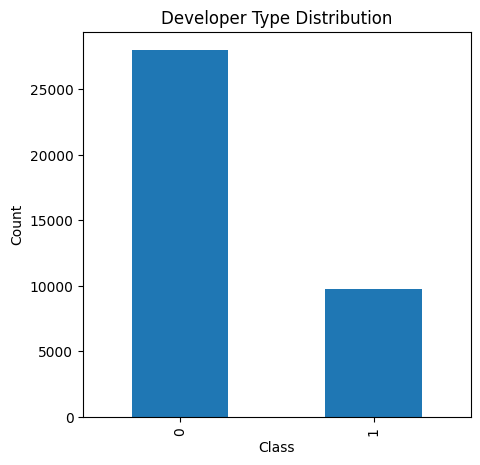

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
targets['ml_target'].value_counts().plot(kind='bar')
plt.title("Developer Type Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
%pip install scipy==1.12.0

In [13]:
from node2vec import Node2Vec

node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=20,
    num_walks=50,
    workers=1
)
model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=4
)

Computing transition probabilities:   0%|          | 0/37700 [00:00<?, ?it/s]

Computing transition probabilities:   2%|▏         | 846/37700 [00:36<26:14, 23.41it/s]  


KeyboardInterrupt: 

In [12]:
embeddings = {}

for node in G.nodes():
    embeddings[node] = model.wv[str(node)]

print(embeddings[0].shape)

NameError: name 'model' is not defined

In [ ]:
len(embeddings)
embeddings[0][:10]